In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv("40-digitalskysurvey.csv")

In [3]:
df.head(3)

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,class,redshift,plate,mjd,fiberid
0,1.237650e+18,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752,301,4,267,3.722360e+18,STAR,-0.000009,3306,54922,491
1,1.237650e+18,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752,301,4,267,3.638140e+17,STAR,-0.000055,323,51615,541
2,1.237650e+18,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752,301,4,268,3.232740e+17,GALAXY,0.123111,287,52023,513


In [4]:
columns_to_drop = ["objid","specobjid","rerun","camcol","field","run"]

In [5]:
df.drop(columns=columns_to_drop, inplace=True)

In [6]:
df.head()

,ra,dec,u,g,r,i,z,class,redshift,plate,mjd,fiberid
0,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,STAR,-0.000009,3306,54922,491
1,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,STAR,-0.000055,323,51615,541
2,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,GALAXY,0.123111,287,52023,513
3,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,STAR,-0.000111,3306,54922,510
4,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,STAR,0.000590,3306,54922,512


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ra        10000 non-null  float64
 1   dec       10000 non-null  float64
 2   u         10000 non-null  float64
 3   g         10000 non-null  float64
 4   r         10000 non-null  float64
 5   i         10000 non-null  float64
 6   z         10000 non-null  float64
 7   class     10000 non-null  object 
 8   redshift  10000 non-null  float64
 9   plate     10000 non-null  int64  
 10  mjd       10000 non-null  int64  
 11  fiberid   10000 non-null  int64  
dtypes: float64(8), int64(3), object(1)
memory usage: 937.6+ KB


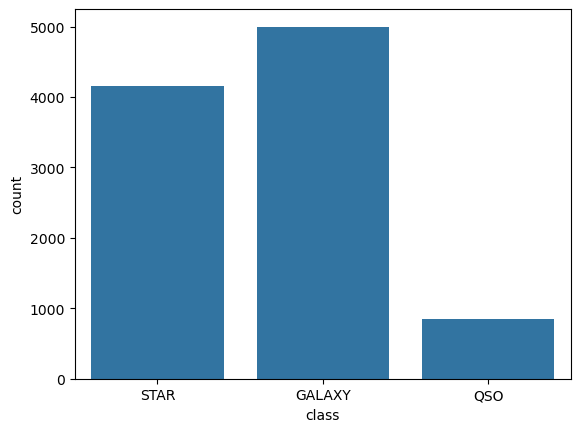

In [8]:
sns.countplot(data=df, x="class")
plt.show()

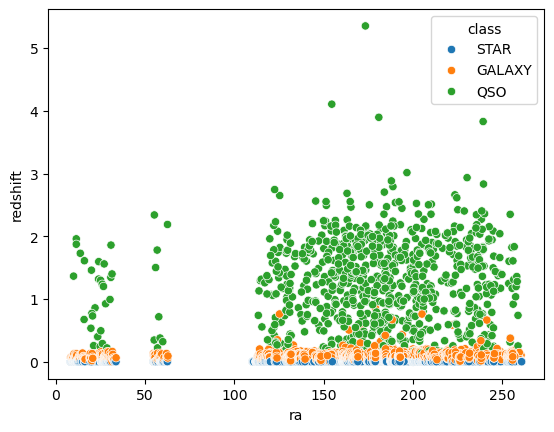

In [9]:
sns.scatterplot(data=df, x='ra', y='redshift', hue='class')
plt.show()

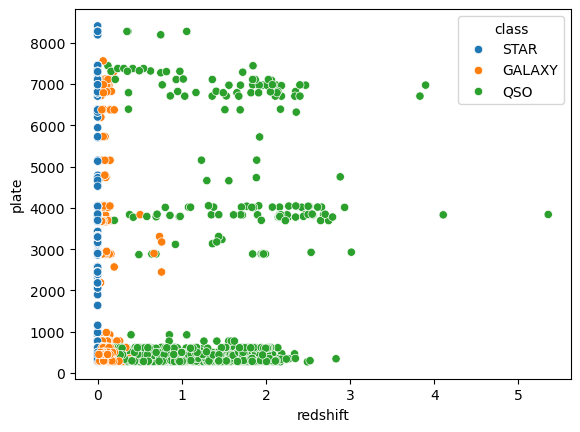

In [10]:
sns.scatterplot(data=df, x="redshift", y="plate", hue="class")
plt.show()

In [11]:
from sklearn.preprocessing import LabelEncoder

In [12]:
label = LabelEncoder()

In [13]:
df['class'] = label.fit_transform(df['class'])

In [14]:
df.head()

,ra,dec,u,g,r,i,z,class,redshift,plate,mjd,fiberid
0,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,2,-0.000009,3306,54922,491
1,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,2,-0.000055,323,51615,541
2,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,0,0.123111,287,52023,513
3,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,2,-0.000111,3306,54922,510
4,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,2,0.000590,3306,54922,512


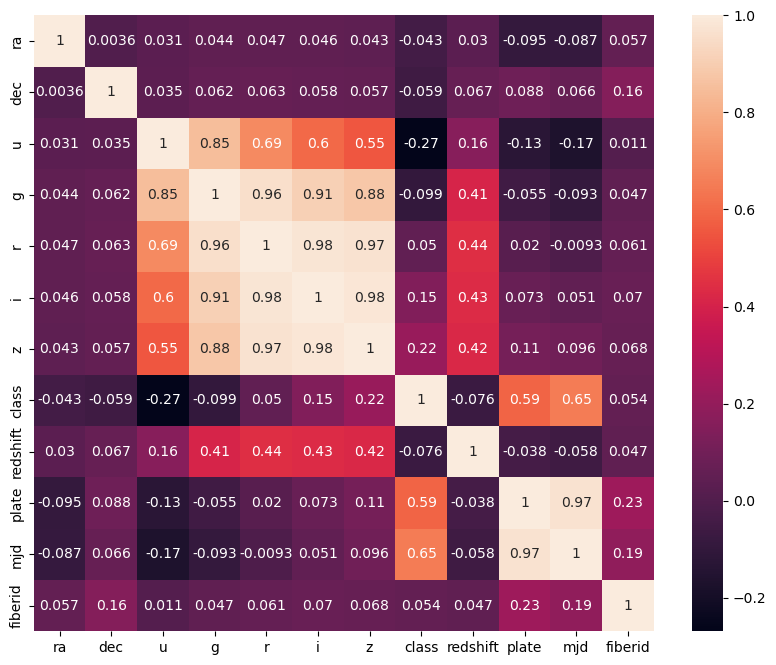

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(data=df.corr(), annot=True)
plt.show()

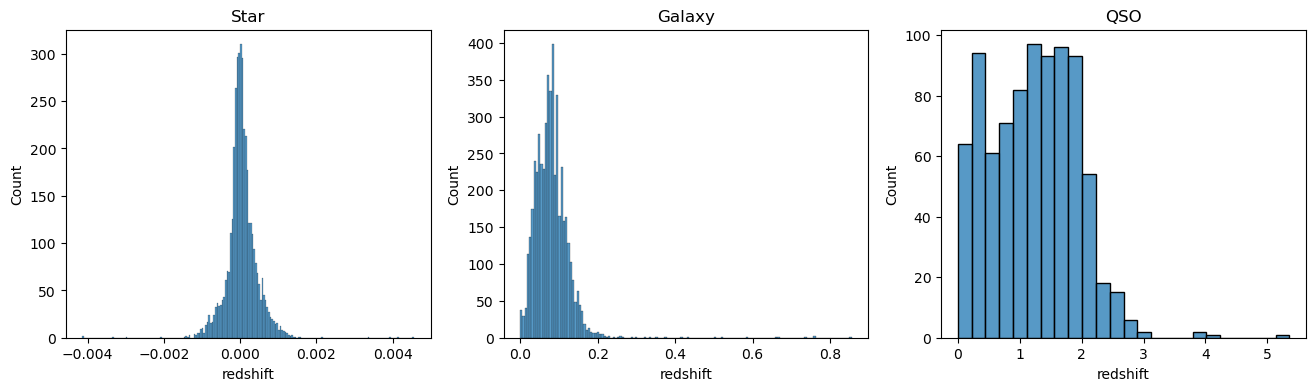

In [16]:
fig, axes = plt.subplots(nrows=1, ncols= 3, figsize=(16,4))
ax = sns.histplot(df[df["class"] == 2].redshift, ax = axes[0])
ax.set_title("Star")
ax = sns.histplot(df[df["class"] == 0].redshift, ax = axes[1])
ax.set_title("Galaxy")
ax = sns.histplot(df[df["class"] == 1].redshift, ax = axes[2])
ax.set_title("QSO")
plt.show()

In [19]:
X = df.drop('class', axis=1)
y = df['class']

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=36)

In [22]:
from xgboost import XGBClassifier

In [23]:
xgb = XGBClassifier()
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [25]:
print("confusion matrix: \n", confusion_matrix(y_pred, y_test))
print("accuracy score: ", accuracy_score(y_pred, y_test))
print(classification_report(y_pred, y_test))

confusion matrix: 
 [[1506   16    3]
 [  10  236    0]
 [   6    0 1223]]
accuracy score:  0.9883333333333333
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1525
           1       0.94      0.96      0.95       246
           2       1.00      1.00      1.00      1229

    accuracy                           0.99      3000
   macro avg       0.97      0.98      0.98      3000
weighted avg       0.99      0.99      0.99      3000



In [26]:
# https://xgboost.readthedocs.io/en/stable/parameter.html

In [29]:
params = {
    'learning_rate' : [0.01, 0.1, 0.3, 1],
    'min_split_loss' : [0, 0.5, 1],
    'max_depth' : [3, 5, 6, 8, 10, 20],
    "colsample_bytree" : [0.3, 0.4, 0.5, 0.8, 1],
    'n_estimators' : [50, 100, 200, 500]
}

In [30]:
from sklearn.model_selection import GridSearchCV

In [31]:
grid = GridSearchCV(estimator=XGBClassifier(), param_grid=params, cv = 5, verbose=3, refit=True, n_jobs=-1, scoring='accuracy')

In [32]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 1440 candidates, totalling 7200 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.3, 0.4, 0.5, 0.8, 1],
                         'learning_rate': [0.01, 0.1, 0.3, 1],
                         'max_depth': [3, 5, 6, 8, 10, 20],
                         'min_split_loss': [0, 0.5, 1],
                         'n_estimators': [50, 100, 200, 500]},
             scoring='accuracy', verbose=3)

In [33]:
y_pred = grid.predict(X_test)

In [34]:
print("confusion matrix: \n", confusion_matrix(y_pred, y_test))
print("accuracy score: ", accuracy_score(y_pred, y_test))
print(classification_report(y_pred, y_test))

confusion matrix: 
 [[1506   18    2]
 [   8  234    0]
 [   8    0 1224]]
accuracy score:  0.988
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1526
           1       0.93      0.97      0.95       242
           2       1.00      0.99      1.00      1232

    accuracy                           0.99      3000
   macro avg       0.97      0.98      0.98      3000
weighted avg       0.99      0.99      0.99      3000

